### WeGo Bus Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("magma")

In [2]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [3]:
#1. What is the overall on-time performance, and what do the overall distribution of adherence look like?

total = len(wego)
on_time_pct = (wego['ADJUSTED_ONTIME_COUNT'].sum() / total) * 100
late_pct = (wego['ADJUSTED_LATE_COUNT'].sum() / total) * 100
early_pct = (wego['ADJUSTED_EARLY_COUNT'].sum() / total) * 100

print(f"Overall On Time Performance: {on_time_pct:.2f}%")
print(f"Overall Late: {late_pct:.2f}%")
print(f"Overall Early: {early_pct:.2f}%")

Overall On Time Performance: 77.08%
Overall Late: 16.85%
Overall Early: 2.79%


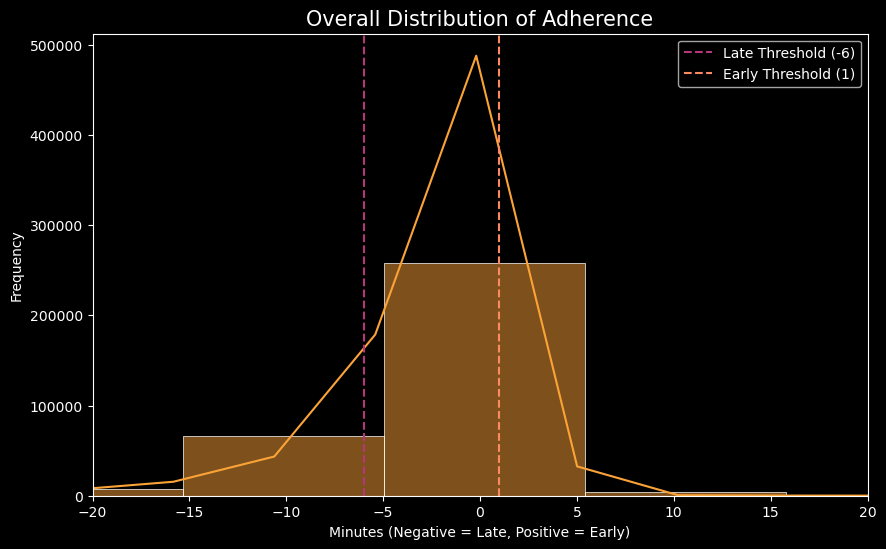

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(wego['ADHERENCE'], bins=100, kde=True, color='#fca338')

plt.style.use('dark_background')

plt.title('Overall Distribution of Adherence', fontsize=15, color='white')
plt.xlabel('Minutes (Negative = Late, Positive = Early)', color='white')
plt.ylabel('Frequency', color='white')

plt.xlim(-20, 20)
plt.axvline(-6, color='#b6367a', linestyle='--', label='Late Threshold (-6)')
plt.axvline(1, color='#fc8961', linestyle='--', label='Early Threshold (1)')
plt.legend()

plt.show()

In [5]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

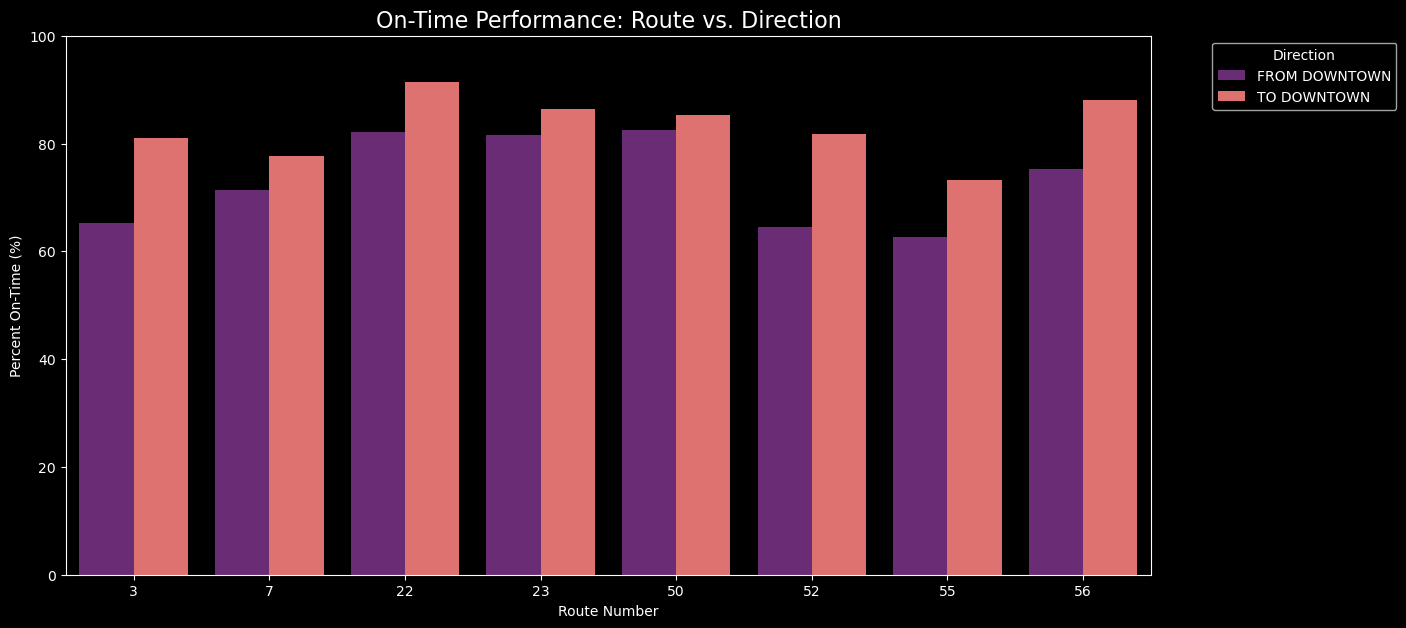

In [6]:
#2. How does direction of travel, route, or location affect the on-time performance?

direction_perf = wego.groupby(['ROUTE_ABBR', 'ROUTE_DIRECTION_NAME'])['ADJUSTED_ONTIME_COUNT'].mean().reset_index()
direction_perf['OTP_Percentage'] = direction_perf['ADJUSTED_ONTIME_COUNT'] * 100

#Chart
plt.figure(figsize=(14, 7))
sns.barplot(
    data=direction_perf,
    x='ROUTE_ABBR',
    y='OTP_Percentage',
    hue='ROUTE_DIRECTION_NAME',
    palette='magma'
)

plt.title('On-Time Performance: Route vs. Direction', fontsize=16)
plt.ylabel('Percent On-Time (%)')
plt.xlabel('Route Number')
plt.ylim(0, 100)
plt.legend(title='Direction', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### Route 3 has a big gap that shows it is significantly more on-time going to downtown(pink) than from dowtown(purple)

##### Route 55 seems to be having the most difficult time with on time performance as they sit the lowest amongst all the others.

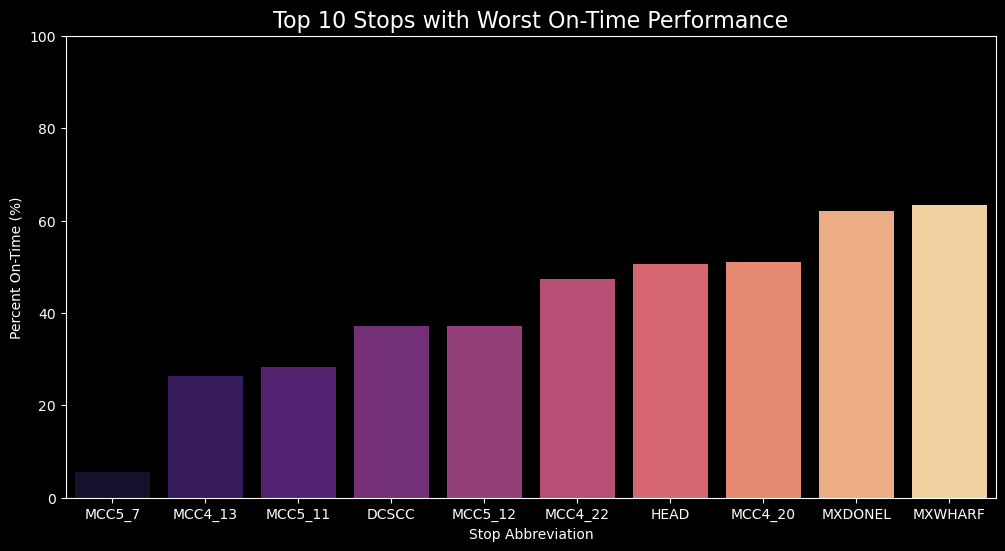

In [7]:
stop_perf = wego.groupby('TIME_POINT_ABBR')['ADJUSTED_ONTIME_COUNT'].mean().sort_values().head(10) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=stop_perf.index, y=stop_perf.values, hue=stop_perf.index, palette='magma', legend=False)

plt.title('Top 10 Stops with Worst On-Time Performance', fontsize=16)
plt.ylabel('Percent On-Time (%)')
plt.xlabel('Stop Abbreviation')
plt.ylim(0, 100)

plt.show()

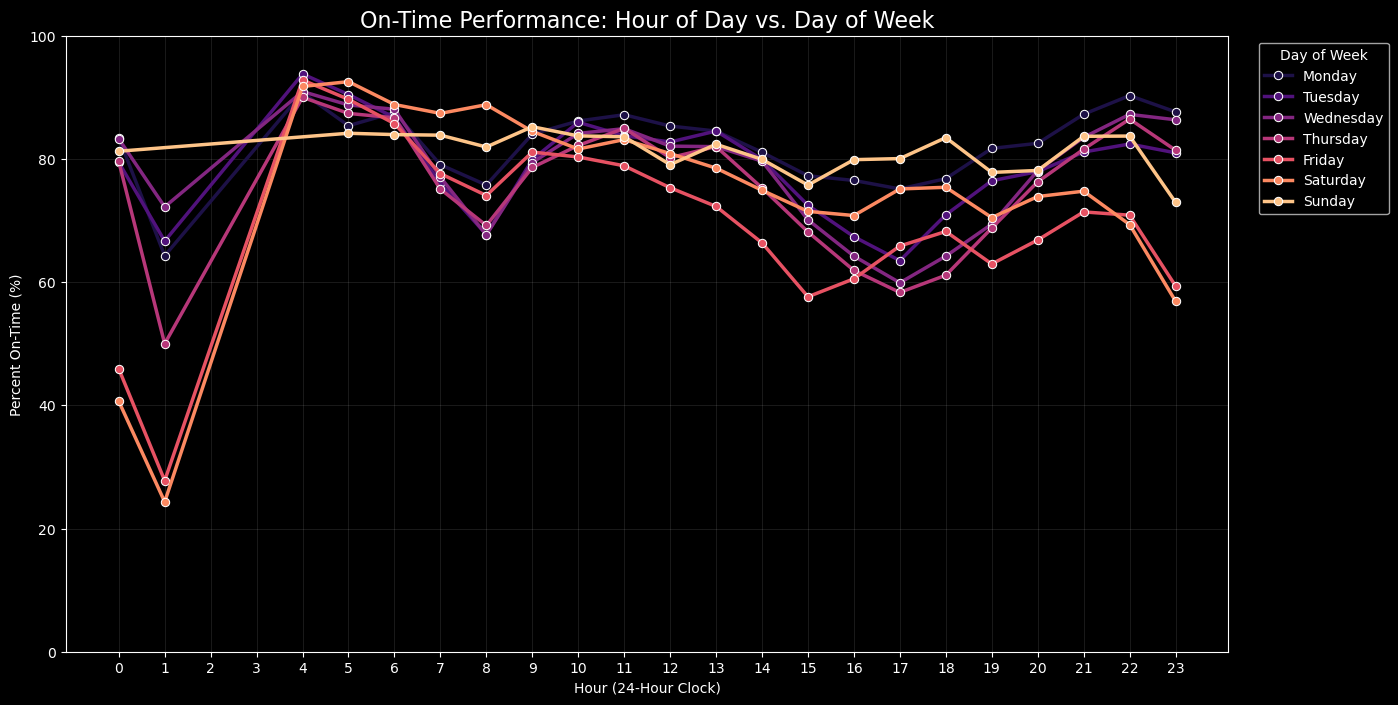

In [8]:
#3. How does time of day or day of week affect on-time performance?

wego['hour'] = pd.to_datetime(wego['SCHEDULED_TIME']).dt.hour
wego['day_of_week'] = pd.to_datetime(wego['DATE']).dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

hourly_day_perf = wego.groupby(['hour', 'day_of_week'])['ADJUSTED_ONTIME_COUNT'].mean().reset_index()
hourly_day_perf['OTP_Percentage'] = hourly_day_perf['ADJUSTED_ONTIME_COUNT'] * 100

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=hourly_day_perf,
    x='hour',
    y='OTP_Percentage',
    hue='day_of_week',
    hue_order=days_order,
    palette='magma',
    linewidth=2.5,
    marker='o'
)    

plt.title('On-Time Performance: Hour of Day vs. Day of Week', fontsize=16)
plt.ylabel('Percent On-Time (%)')
plt.xlabel('Hour (24-Hour Clock)')
plt.xticks(range(0, 24))
plt.ylim(0, 100)
plt.grid(True, alpha=0.1)
plt.legend(title='Day of Week', bbox_to_anchor=(1.02,1), loc='upper left')

plt.show()


Analysis:

There is a significant pattern where there is a decline in on-time performance starting at the 1:00pm hour mark to the 5:00pm hour mark. Which can generally be described as rush hour traffic results in a lot of the city wide delays.

Friday and Saturday Nights showed a consistent downward trend of delays

Also, after 1:00 am there is a significant downward trend in performance, showing that the few late-night buses are consistently off-schedule.


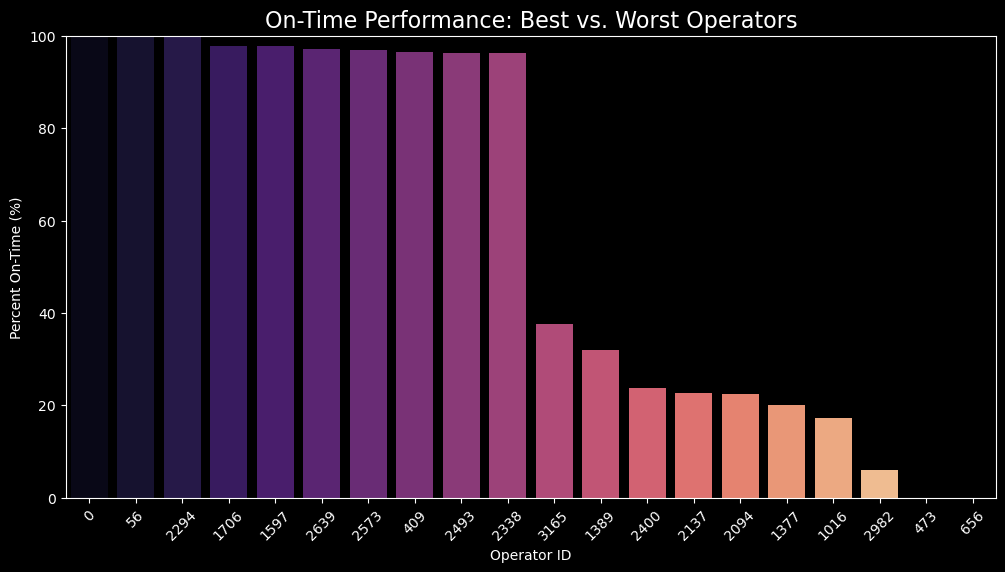

In [9]:
#4. How much of a factor does the driver have on on-time performance? 
# The driver is indicated by the OPERATOR variable.

driver_perf = wego.groupby('OPERATOR')['ADJUSTED_ONTIME_COUNT'].mean() * 100

top_drivers = driver_perf.sort_values(ascending=False).head(10)
bottom_drivers = driver_perf.sort_values(ascending=False).tail(10)

comparison = pd.concat([top_drivers, bottom_drivers])

plt.figure(figsize=(12,6))
sns.barplot(
    x=comparison.index.astype(str),
    y=comparison.values,
    hue=comparison.index.astype(str),
    palette='magma',
    legend=False
)

plt.title('On-Time Performance: Best vs. Worst Operators', fontsize=16)
plt.ylabel('Percent On-Time (%)')
plt.xlabel('Operator ID')
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

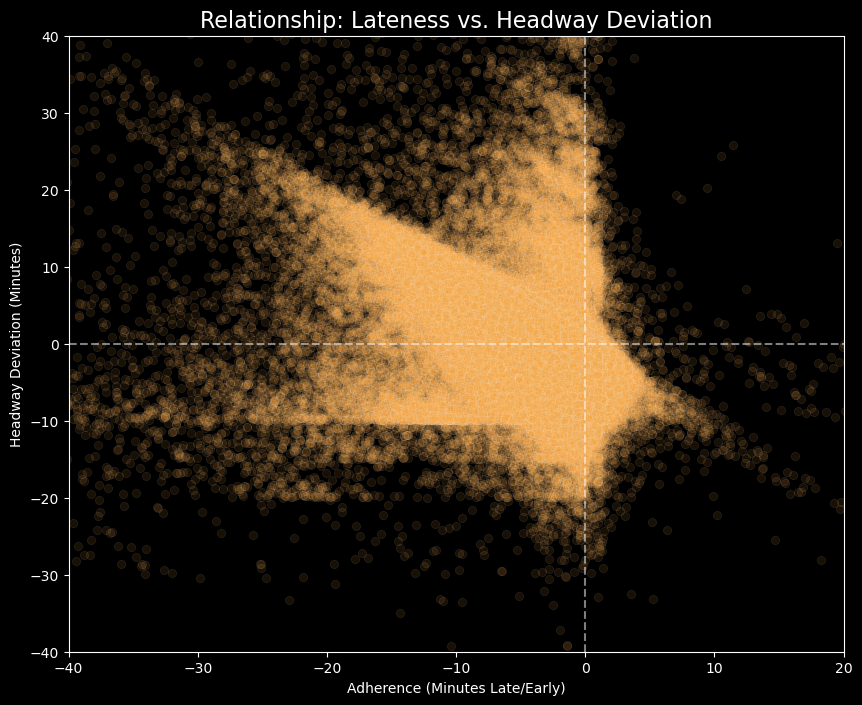

In [10]:
#5. Is there any relationship between lateness (ADHERENCE) and headway deviation? 
# The headway deviation variable is contained in the HDWY_DEV column. 
# See the notes under number 9 for a description of headway and headway deviation.

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=wego,
    x='ADHERENCE',
    y='HDWY_DEV',
    alpha=0.1,
    color='#fca338'
)

plt.axvline(0, color='white', linestyle='--', alpha=0.5)
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title('Relationship: Lateness vs. Headway Deviation', fontsize=16)
plt.xlabel('Adherence (Minutes Late/Early)')
plt.ylabel('Headway Deviation (Minutes)')

plt.xlim(-40, 20)
plt.ylim(-40, 40)

plt.show()

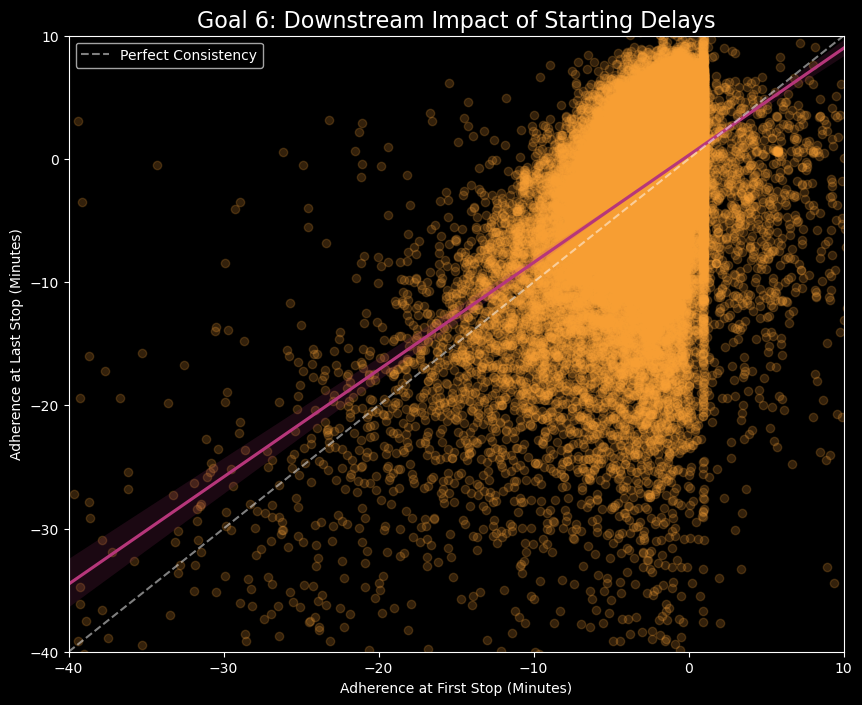

In [11]:
#6. How much impact does being late or too spaced out at the first stop have downstream?

first_stop = wego[wego['TRIP_EDGE'] == 1][['CALENDAR_ID', 'TRIP_ID', 'ADHERENCE', 'HDWY_DEV']]
last_stop = wego[wego['TRIP_EDGE'] == 2][['CALENDAR_ID', 'TRIP_ID', 'ADHERENCE', 'HDWY_DEV']]

downstream = pd.merge(first_stop, last_stop, on=['CALENDAR_ID', 'TRIP_ID'], suffixes=('_start', '_end'))

plt.figure(figsize=(10, 8))
sns.regplot(data=downstream, x='ADHERENCE_start', y='ADHERENCE_end',
            scatter_kws={'alpha':0.2, 'color':'#fca338'},
            line_kws={'color':'#b6367a'})

plt.title('Goal 6: Downstream Impact of Starting Delays', fontsize=16)
plt.xlabel('Adherence at First Stop (Minutes)')
plt.ylabel('Adherence at Last Stop (Minutes)')

plt.plot([-40, 10], [-40, 10], color='white', linestyle='--', alpha=0.5, label='Perfect Consistency')

plt.xlim(-40, 10)
plt.ylim(-40, 10)
plt.legend()

plt.show()


Analysis:

The "Stay Late" Trend: 
Looking at the trend line, it is very cleasr thast if you start behind, then you end up staying behind. If a trip starts 10 minutes late, it is almost certain to end as late as that. In my experience, once the clock starts ticking against you, its a constant uphill battle to get back on schedule.

The "Sinking" Effect: 
All those dots below the dashed line tell the real story. it is basically showing how easy it is to lose more time than it is to make it up. Drivers arent just manipulating the delay; they are often getting swallowed by it. This shows that "recovery time" on those routes is almost non-existent once things go sideways.

The Wall at Zero: 
Noticing the huge vertical line of dots right at 0 on the bottom axis. This shows that even buses that start perfectly on time often end up 10, 20, or even 30 minutes late by the end of the route.


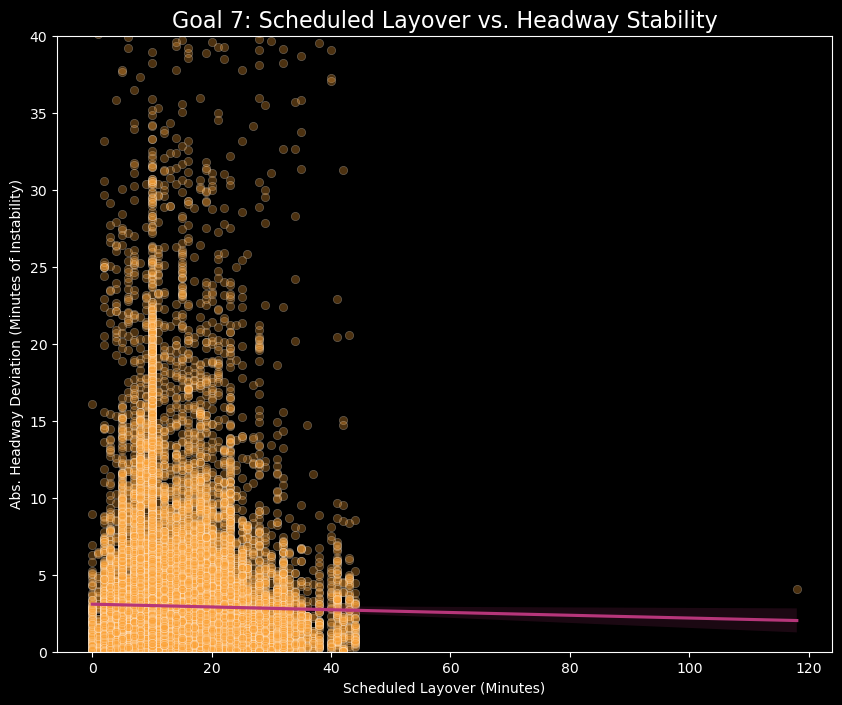

In [12]:
#7. What is the impact of the layover at the start of the trip (the difference between the first stop arrival and departure time)? 
# Does more dwell time at the beginning of a trip lead to more stable headways (lower values for % headway deviation)? 
# Do trips with longer scheduled layover time have more stable headway values?

trip_starts = wego[wego['TRIP_EDGE'] == 1].copy()

trip_starts['abs_hdwy_dev'] = trip_starts['HDWY_DEV'].abs()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=trip_starts, 
    x='SCHEDULED_LAYOVER_MINUTES', 
    y='abs_hdwy_dev', 
    alpha=0.3, 
    color='#fca338'
)

sns.regplot(
    data=trip_starts, 
    x='SCHEDULED_LAYOVER_MINUTES', 
    y='abs_hdwy_dev', 
    scatter=False, 
    color='#b6367a'
)

plt.title('Goal 7: Scheduled Layover vs. Headway Stability', fontsize=16)
plt.xlabel('Scheduled Layover (Minutes)')
plt.ylabel('Abs. Headway Deviation (Minutes of Instability)')
plt.ylim(0, 40)

plt.show()


Analysis:

The Trend: Because the line slopes down, you can conclude that longer scheduled layovers do lead to more stable headways. When drivers have more "buffer" time at the start, they are less likely to have massive gaps (instability) in their timing.

Also, notice how most of the data is clustered between 0 and 20 minutes of the layover. This is where the most instability happens (the tall orange spikes). Once the layover gets closer to 40 minutes, the instability (Headway Deviation) settles down significantly.

You even have one trip way out at 120 minutes of layover that has almost zero instability!

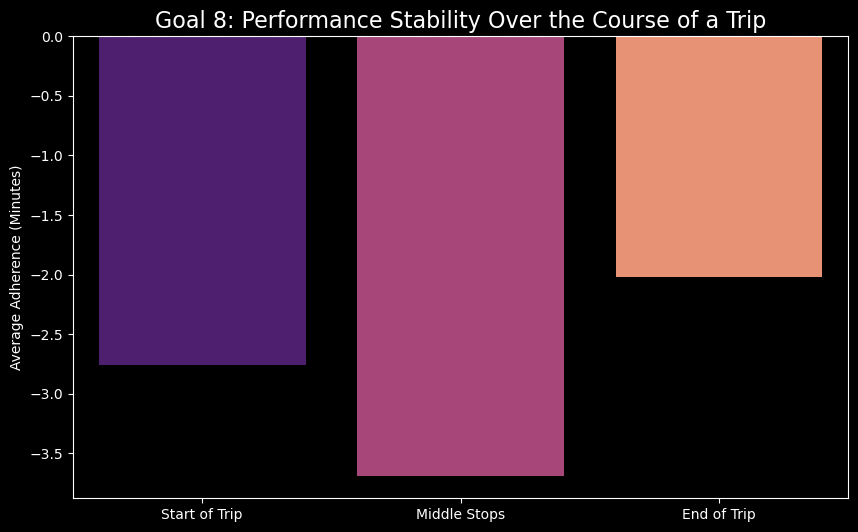

In [13]:
#8. What is the relationship between distance or time traveled since the start of a given trip and the adherence value? 
# Does on-time performance become less stable the further along the route the bus has traveled?

journey_perf = wego.groupby('TRIP_EDGE')['ADHERENCE'].mean().reindex([1, 0, 2])

plt.figure(figsize=(10, 6))
sns.barplot(x=['Start of Trip', 'Middle Stops', 'End of Trip'], 
            y=journey_perf.values, 
            hue=['Start', 'Middle', 'End'],
            palette='magma',
            legend=False)

plt.title('Goal 8: Performance Stability Over the Course of a Trip', fontsize=16)
plt.ylabel('Average Adherence (Minutes)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.show()


Analysis:

The Middle Stops (purple/pink bar) are the most delayed, dropping down to nearly -3.7 minutes on average. This is where buses get hit hardest by traffic and passenger pick-ups.

I also noticed how the End of Trip (orange bar) actually moves back up toward zero. This suggests that as buses reach the end of their route, they often have some "buffer" time or fewer stops, allowing them to recover slightly from the middle-of-the-trip delays.

It is clear that performance is definitely not stable. The fact that the average adherence jumps around by more than a minute between the start and the middle shows that the further a bus travels, the more unpredictable its schedule becomes.


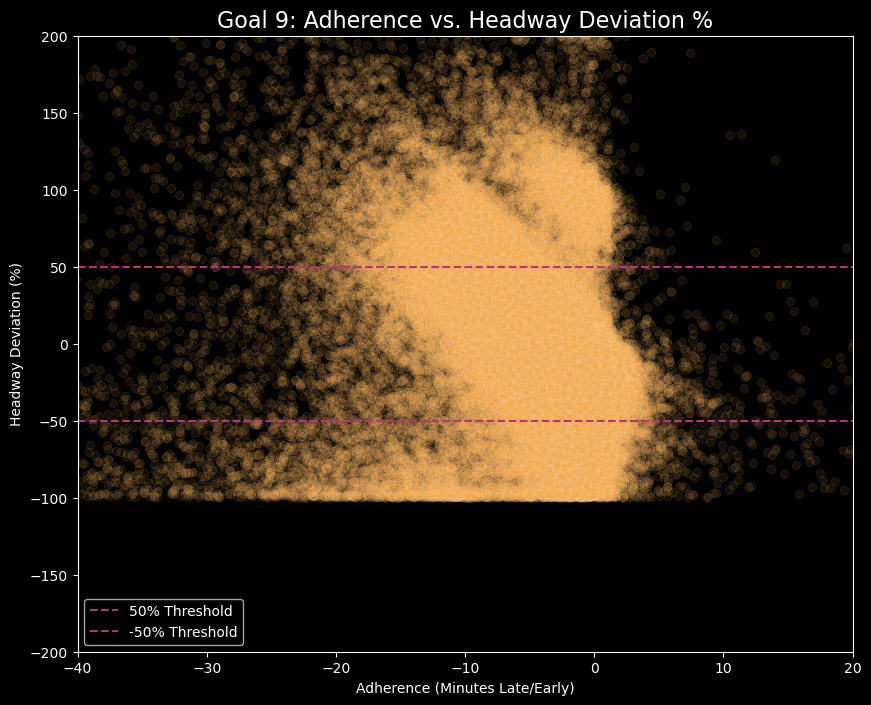

In [14]:
#9. Headway Deviation

wego['hdwy_dev_pct'] = (wego['HDWY_DEV'] / wego['SCHEDULED_HDWY']) * 100

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=wego, 
    x='ADHERENCE', 
    y='hdwy_dev_pct', 
    alpha=0.1, 
    color='#fca338'
)

plt.axhline(50, color='#b6367a', linestyle='--', label='50% Threshold')
plt.axhline(-50, color='#b6367a', linestyle='--', label='-50% Threshold')

plt.title('Goal 9: Adherence vs. Headway Deviation %', fontsize=16)
plt.xlabel('Adherence (Minutes Late/Early)')
plt.ylabel('Headway Deviation (%)')
plt.xlim(-40, 20)
plt.ylim(-200, 200)

plt.legend()
plt.show()


Analysis:

The "Danger Zone": 
Seeing all that bright orange color outside the pink dashed lines shows all the times the bus service was "unacceptable" (deviating by more than 50%).

The "Lateness" Link: 
As the dots move to the left (indicating more late), the cloud gets much wider. This proves that lateness is the primary cause of unstable headways. The more late a bus is, the more likely it is to "bunch" or "gap" out of the acceptable range.

The only place where the data stays mostly inside the pink lines is right around 0 mark(on-time). This confirms that on-time performance is the only way to keep the gaps between buses stable.
